# Week 6: Channel-Based Sampling — TED and TEDx

This notebook initiates a pivot to channel-based sampling by collecting all videos
from the official TED and TEDx YouTube channels. The goal is to construct a
systematic dataset of expert discourse on YouTube while reusing the sentiment
analysis pipeline developed in earlier weeks.


In [1]:
!git clone https://github.com/mustafayubk/SOSC314_Project.git
%cd SOSC314_Project
!ls


Cloning into 'SOSC314_Project'...
remote: Enumerating objects: 404, done.
remote: Counting objects: 100% (205/205), done.
remote: Compressing objects: 100% (204/204), done.
remote: Total 404 (delta 120), reused 0 (delta 0), pack-reused 199 (from 2)
Receiving objects: 100% (404/404), 10.36 MiB | 12.21 MiB/s, done.
Resolving deltas: 100% (220/220), done.
/content/SOSC314_Project
 config   docs	      README.md  'Week 2_Figure.png'
 data	  notebooks   scripts	  Week_3_Figure.png


In [2]:
import os

os.makedirs("notebooks/week6", exist_ok=True)


## Step 1: Retrieve all videos from TED and TEDx channels

This step uses the YouTube Data API to collect metadata for all videos
uploaded by the official TED and TEDx channels. This provides a systematic,
channel-based sampling frame for expert discourse on YouTube.


In [9]:
!pip -q install google-api-python-client pandas tqdm


In [10]:
import os
import pandas as pd
from tqdm import tqdm
from googleapiclient.discovery import build


In [11]:
from google.colab import userdata


In [12]:
API_KEY = userdata.get("YOUTUBE_API_KEY") or userdata.get("YOUTUBE")

print("Has key?", API_KEY is not None)

if not API_KEY:
    raise ValueError("YouTube API key not found. In Colab Secrets, create YOUTUBE_API_KEY (or YOUTUBE) and enable Notebook access.")

youtube = build("youtube", "v3", developerKey=API_KEY)
print("YouTube client built ✅")


Has key? True
YouTube client built ✅


In [13]:
CHANNELS = {
    "TED": "UCAuUUnT6oDeKwE6v1NGQxug",
    "TEDx": "UCsT0YIqwnpJCM-mx7-gSA4Q"
}


In [14]:
def get_all_videos_from_channel(channel_id, channel_name):
    videos = []
    next_page = None

    while True:
        request = youtube.search().list(
            part="snippet",
            channelId=channel_id,
            maxResults=50,
            pageToken=next_page,
            type="video",
            order="date"
        )
        response = request.execute()

        for item in response["items"]:
            videos.append({
                "video_id": item["id"]["videoId"],
                "title": item["snippet"]["title"],
                "channel": channel_name,
                "published_at": item["snippet"]["publishedAt"]
            })

        next_page = response.get("nextPageToken")
        if not next_page:
            break

    return videos


In [15]:
all_videos = []

for name, cid in CHANNELS.items():
    print(f"Collecting videos from {name}...")
    vids = get_all_videos_from_channel(cid, name)
    print(f"  → {len(vids)} videos found")
    all_videos.extend(vids)


  → 9 videos found
  → 100 videos found


In [16]:
def get_uploads_playlist_id(channel_id: str) -> str:
    resp = youtube.channels().list(
        part="contentDetails",
        id=channel_id
    ).execute()
    items = resp.get("items", [])
    if not items:
        raise ValueError(f"No channel found for channel_id={channel_id}")
    return items[0]["contentDetails"]["relatedPlaylists"]["uploads"]

for name, cid in CHANNELS.items():
    upl = get_uploads_playlist_id(cid)
    print(name, "uploads playlist:", upl)


TED uploads playlist: UUAuUUnT6oDeKwE6v1NGQxug
TEDx uploads playlist: UUsT0YIqwnpJCM-mx7-gSA4Q


In [17]:
def get_all_videos_from_uploads_playlist(uploads_playlist_id: str, channel_name: str):
    videos = []
    page_token = None

    while True:
        resp = youtube.playlistItems().list(
            part="snippet,contentDetails",
            playlistId=uploads_playlist_id,
            maxResults=50,
            pageToken=page_token
        ).execute()

        for item in resp.get("items", []):
            # playlistItems gives videoId + publishedAt inside contentDetails
            vid = item["contentDetails"]["videoId"]
            published_at = item["contentDetails"].get("videoPublishedAt") or item["snippet"].get("publishedAt")
            title = item["snippet"]["title"]

            videos.append({
                "video_id": vid,
                "title": title,
                "channel": channel_name,
                "published_at": published_at
            })

        page_token = resp.get("nextPageToken")
        if not page_token:
            break

    return videos

all_videos = []
for name, cid in CHANNELS.items():
    uploads = get_uploads_playlist_id(cid)
    print(f"Collecting ALL uploads from {name}…")
    vids = get_all_videos_from_uploads_playlist(uploads, name)
    print(f"  → {len(vids)} videos found")
    all_videos.extend(vids)

print("TOTAL videos:", len(all_videos))


  → 5491 videos found
  → 20000 videos found
TOTAL videos: 25491


In [18]:
import pandas as pd

videos_df = pd.DataFrame(all_videos)
videos_df["published_at"] = pd.to_datetime(videos_df["published_at"], errors="coerce")

print(videos_df.groupby("channel")["video_id"].nunique())
print("Earliest by channel:")
print(videos_df.sort_values("published_at").groupby("channel").head(1)[["channel","published_at","title"]])
print("Latest by channel:")
print(videos_df.sort_values("published_at").groupby("channel").tail(1)[["channel","published_at","title"]])


channel
TED      5491
TEDx    20000
Name: video_id, dtype: int64
Earliest by channel:
      channel              published_at  \
5490      TED 2006-12-25 17:58:08+00:00   
25490    TEDx 2025-05-01 15:30:39+00:00   

                                                   title  
5490                If I controlled the Internet | Rives  
25490  Why you should make a ‘done’ list | Francis Ru...  
Latest by channel:
     channel              published_at  \
5491    TEDx 2026-02-08 14:30:11+00:00   
0        TED 2026-02-08 19:00:41+00:00   

                                                  title  
5491  How do non-living things ‘evolve’? | Michael W...  
0        What if plastic didn’t last forever? #TEDTalks  


In [19]:
import os
import pandas as pd

# Create folder if it doesn't exist
os.makedirs("data/raw/week6", exist_ok=True)

videos_df = pd.DataFrame(all_videos)

# (Optional but recommended) remove any duplicates just in case
videos_df = videos_df.drop_duplicates(subset=["video_id"])

out_path = "data/raw/week6/ted_tedx_videos.csv"
videos_df.to_csv(out_path, index=False)

print("Saved:", len(videos_df), "videos to", out_path)
videos_df.head()


Saved: 25491 videos to data/raw/week6/ted_tedx_videos.csv


,video_id,title,channel,published_at
0,iOTCsXd38Ng,What if plastic didn’t last forever? #TEDTalks,TED,2026-02-08T19:00:41Z
1,d1yfb93beSI,How to Introduce Yourself — and Get Hired | Re...,TED,2026-02-08T16:00:53Z
2,yrVtEkCC8uY,These ads could encourage people to think twic...,TED,2026-02-07T19:01:00Z
3,an6ZM0iCGQw,Let’s Build AI Data Centers in Space | Philip ...,TED,2026-02-06T16:00:07Z
4,bA9xGDsQADo,Today’s athletes ARE built different #TEDTalks,TED,2026-02-05T20:00:34Z


In [20]:
import os, glob
print("Folder exists?", os.path.exists("data/raw/week6"))
print("Files:", glob.glob("data/raw/week6/*"))


Folder exists? True
Files: ['data/raw/week6/ted_tedx_videos.csv']


## Week 6: Channel-Based Sampling Frame (TED & TEDx)

This section constructs the full population of TED and TEDx videos
and assigns each video to a publication-period time bin.

All subsequent comment scraping and sentiment analysis will operate
on this fixed channel-level sampling frame to ensure reproducibility
and comparability across time.


In [21]:
# Fix: ensure published_at is a proper datetime (not a string)
videos_df["published_at"] = pd.to_datetime(videos_df["published_at"], errors="coerce")

print("Null dates after conversion:", videos_df["published_at"].isna().sum())
print("Example:", videos_df["published_at"].dropna().iloc[0])


Null dates after conversion: 0
Example: 2026-02-08 19:00:41+00:00


In [22]:
# Define publication-period bins (same logic as earlier weeks)
def assign_time_bin(dt):
    year = dt.year
    if year < 2010:
        return "Pre-2010"
    elif year < 2020:
        return "2010–2019"
    else:
        return "2020+"

videos_df["time_bin"] = videos_df["published_at"].apply(assign_time_bin)

# Quick sanity check
videos_df.groupby(["channel", "time_bin"])["video_id"].nunique()


channel  time_bin 
TED      2010–2019     2620
         2020+         2300
         Pre-2010       571
TEDx     2020+        20000
Name: video_id, dtype: int64

In [23]:
# 3️⃣ Save the finalized sampling frame (Week 6 core artifact)

import os

out_path = "data/processed/week6/ted_tedx_video_sampling_frame.csv"
os.makedirs("data/processed/week6", exist_ok=True)

videos_df.to_csv(out_path, index=False)

print("Saved sampling frame to:", out_path)
print("Rows:", videos_df.shape[0])
print("Columns:", videos_df.columns.tolist())


Saved sampling frame to: data/processed/week6/ted_tedx_video_sampling_frame.csv
Rows: 25491
Columns: ['video_id', 'title', 'channel', 'published_at', 'time_bin']


## Week 6 — Comment Scraping Scaffold (Test Run)

Now that we have a full TED + TEDx video sampling frame, the next step is to scrape
top-level comments for each video.

To keep the pipeline comparable to earlier weeks and manageable under API quota,
I start by scraping **top-level comments only** (no replies) and I cap the number
of comments per video (I will justify this in the Week 6 report).

Before scraping the full dataset, we do a small **test run** on a few videos to confirm:
- the API calls work
- the output format is correct
- comments are actually being collected and saved


In [24]:
import time
import pandas as pd

def get_top_level_comments(video_id, max_comments=200, sleep_s=0.1):
    """
    Scrape up to max_comments top-level comments (no replies) from a YouTube video.
    Returns a list of dicts.
    """
    comments = []
    next_page = None

    while len(comments) < max_comments:
        req = youtube.commentThreads().list(
            part="snippet",
            videoId=video_id,
            maxResults=min(100, max_comments - len(comments)),
            pageToken=next_page,
            textFormat="plainText",
            order="time"  # consistent ordering
        )
        res = req.execute()

        items = res.get("items", [])
        for it in items:
            sn = it["snippet"]["topLevelComment"]["snippet"]
            comments.append({
                "video_id": video_id,
                "comment_id": it["snippet"]["topLevelComment"]["id"],
                "text": sn.get("textDisplay", ""),
                "like_count": sn.get("likeCount", 0),
                "published_at": sn.get("publishedAt", "")
            })

        next_page = res.get("nextPageToken")
        if not next_page:
            break

        time.sleep(sleep_s)

    return comments


# ---------------------------
# TEST RUN (tiny sample)
# ---------------------------
# Pick a few videos from your sampling frame
test_ted = videos_df[videos_df["channel"] == "TED"]["video_id"].head(2).tolist()
test_tedx = videos_df[videos_df["channel"] == "TEDx"]["video_id"].head(2).tolist()
test_ids = test_ted + test_tedx

print("Test video IDs:", test_ids)

all_test_comments = []
for vid in test_ids:
    try:
        batch = get_top_level_comments(vid, max_comments=200)
        print(f"{vid}: collected {len(batch)} comments")
        all_test_comments.extend(batch)
    except Exception as e:
        print(f"{vid}: FAILED -> {e}")

# Save test output
import os
os.makedirs("data/raw/week6", exist_ok=True)

test_df = pd.DataFrame(all_test_comments)
out_path = "data/raw/week6/comments_test_sample.csv"
test_df.to_csv(out_path, index=False)

print("Saved test comments to:", out_path)
test_df.head()


Test video IDs: ['iOTCsXd38Ng', 'd1yfb93beSI', 'DSrf7ErdHWA', 'TEf0EV3mVWw']
iOTCsXd38Ng: collected 10 comments
d1yfb93beSI: collected 37 comments
DSrf7ErdHWA: collected 14 comments
TEf0EV3mVWw: collected 23 comments
Saved test comments to: data/raw/week6/comments_test_sample.csv


,video_id,comment_id,text,like_count,published_at
0,iOTCsXd38Ng,UgxaVM4LSOrH4e0Pamt4AaABAg,Sand and Silica is are among the Most abundant...,1,2026-02-08T23:58:52Z
1,iOTCsXd38Ng,UgywYl7CRxnk1yUoWCR4AaABAg,"Plastic is everywhere and I mean everywhere, ...",0,2026-02-08T23:00:34Z
2,iOTCsXd38Ng,Ugyqmuz52AJOZBUTynd4AaABAg,Brava❤,1,2026-02-08T22:11:44Z
3,iOTCsXd38Ng,UgzB3f0d76GDGn7uL6B4AaABAg,Amazing! My respects.,1,2026-02-08T22:02:43Z
4,iOTCsXd38Ng,UgzLsOVSfvA8jzipqJ54AaABAg,IT IS A LIE! WE KNOW IT. DONT FOOL US ANY MORE...,3,2026-02-08T20:46:49Z


## Week 6 — Full Comment Scrape (Chunked + Resume-Friendly)

We now scrape comments for the full TED + TEDx sampling frame.
To avoid losing progress and to keep files manageable, we save data in chunks.
Each chunk contains comments for a fixed number of videos.

If Colab disconnects or quota is hit, we can resume from the last completed chunk.


In [25]:
import os
import pandas as pd
import time

# ---------- SETTINGS ----------
MAX_COMMENTS_PER_VIDEO = 500     # consistent with earlier weeks
VIDEOS_PER_CHUNK = 25            # adjust later if needed (25 is safe)
SLEEP_BETWEEN_CALLS = 0.1        # tiny delay to be polite

# Save folder
RAW_DIR = "data/raw/week6"
os.makedirs(RAW_DIR, exist_ok=True)

# Load sampling frame (from your committed CSV)
frame_path = "data/processed/week6/ted_tedx_video_sampling_frame.csv"
videos_df = pd.read_csv(frame_path)

# Safety: ensure correct columns exist
needed_cols = {"video_id", "channel", "published_at", "time_bin"}
missing = needed_cols - set(videos_df.columns)
if missing:
    raise ValueError(f"Sampling frame missing columns: {missing}")

# ---------- RESUME LOGIC ----------
# We'll store a small progress file that tracks which videos are already done
progress_path = f"{RAW_DIR}/scrape_progress.csv"

if os.path.exists(progress_path):
    progress_df = pd.read_csv(progress_path)
    done_ids = set(progress_df["video_id"].astype(str))
    print("Resuming: already scraped videos =", len(done_ids))
else:
    done_ids = set()
    progress_df = pd.DataFrame(columns=["video_id", "status", "n_comments"])
    print("Starting fresh scrape")

# Filter videos that still need scraping
todo = videos_df[~videos_df["video_id"].astype(str).isin(done_ids)].copy()
todo_ids = todo["video_id"].astype(str).tolist()

print("Videos remaining to scrape:", len(todo_ids))

# ---------- SCRAPE 1 CHUNK ONLY (for Tuesday Commit 1) ----------
# We only scrape the FIRST chunk today to prove full pipeline works.
chunk_ids = todo_ids[:VIDEOS_PER_CHUNK]
print("Scraping this chunk size:", len(chunk_ids))

all_comments = []
new_progress_rows = []

for i, vid in enumerate(chunk_ids, start=1):
    try:
        batch = get_top_level_comments(vid, max_comments=MAX_COMMENTS_PER_VIDEO, sleep_s=SLEEP_BETWEEN_CALLS)
        all_comments.extend(batch)
        new_progress_rows.append({"video_id": vid, "status": "ok", "n_comments": len(batch)})
        print(f"[{i}/{len(chunk_ids)}] {vid}: {len(batch)} comments")
    except Exception as e:
        new_progress_rows.append({"video_id": vid, "status": f"fail: {e}", "n_comments": 0})
        print(f"[{i}/{len(chunk_ids)}] {vid}: FAILED -> {e}")

# Convert and merge metadata (channel + time_bin)
comments_df = pd.DataFrame(all_comments)
comments_df = comments_df.merge(videos_df[["video_id","channel","time_bin"]], on="video_id", how="left")

# Save this chunk
chunk_index = len(done_ids) // VIDEOS_PER_CHUNK
chunk_path = f"{RAW_DIR}/comments_chunk_{chunk_index:03d}.csv"
comments_df.to_csv(chunk_path, index=False)

# Update progress log
progress_df = pd.concat([progress_df, pd.DataFrame(new_progress_rows)], ignore_index=True)
progress_df.to_csv(progress_path, index=False)

print("✅ Saved chunk to:", chunk_path)
print("✅ Updated progress log:", progress_path)
print("Chunk rows:", len(comments_df))
comments_df.head()


Starting fresh scrape
Videos remaining to scrape: 25491
Scraping this chunk size: 25
[1/25] iOTCsXd38Ng: 10 comments
[2/25] d1yfb93beSI: 37 comments
[3/25] yrVtEkCC8uY: 4 comments
[4/25] an6ZM0iCGQw: 79 comments
[5/25] bA9xGDsQADo: 6 comments
[6/25] kryWR7QNBkc: 29 comments
[7/25] c7rtbTnmnzI: 13 comments
[8/25] HtzG2AoahAo: 23 comments
[9/25] -CAzAfDhbwU: 9 comments
[10/25] vkHuZY-x5DA: 21 comments
[11/25] 7IYKojMhBy4: 27 comments
[12/25] roc73qEYhXY: 14 comments
[13/25] X564_fIhp_0: 500 comments
[14/25] VoPDKjFHIDU: 45 comments
[15/25] VFY6NTaw9mM: 45 comments
[16/25] YBH8rQv4aTQ: 53 comments
[17/25] Mqk_j_248MU: 15 comments
[18/25] E74vI_Nrn4k: 9 comments
[19/25] LsM8fyov0iI: 15 comments
[20/25] IuzK04m-Px4: 14 comments
[21/25] VA2hdDoSM4s: 74 comments
[22/25] E6oZzu_ui0E: 11 comments
[23/25] vsMqvHqnRUs: 60 comments
[24/25] aWGu4owdXrM: 14 comments
[25/25] ojttMNOW6zM: 500 comments
✅ Saved chunk to: data/raw/week6/comments_chunk_000.csv
✅ Updated progress log: data/raw/week6/scrape

,video_id,comment_id,text,like_count,published_at,channel,time_bin
0,iOTCsXd38Ng,UgxaVM4LSOrH4e0Pamt4AaABAg,Sand and Silica is are among the Most abundant...,1,2026-02-08T23:58:52Z,TED,2020+
1,iOTCsXd38Ng,UgywYl7CRxnk1yUoWCR4AaABAg,"Plastic is everywhere and I mean everywhere, ...",0,2026-02-08T23:00:34Z,TED,2020+
2,iOTCsXd38Ng,Ugyqmuz52AJOZBUTynd4AaABAg,Brava❤,1,2026-02-08T22:11:44Z,TED,2020+
3,iOTCsXd38Ng,UgzB3f0d76GDGn7uL6B4AaABAg,Amazing! My respects.,1,2026-02-08T22:02:43Z,TED,2020+
4,iOTCsXd38Ng,UgzLsOVSfvA8jzipqJ54AaABAg,IT IS A LIE! WE KNOW IT. DONT FOOL US ANY MORE...,3,2026-02-08T20:46:49Z,TED,2020+


In [26]:
import os
import pandas as pd
import time

# ---------- SETTINGS ----------
MAX_COMMENTS_PER_VIDEO = 500
VIDEOS_PER_CHUNK = 25

# For Tuesday commit 2: run multiple chunks in one go
NUM_CHUNKS_TO_RUN_NOW = 4   # 4 chunks × 25 vids = 100 videos today (safe)
SLEEP_BETWEEN_CALLS = 0.1

RAW_DIR = "data/raw/week6"
os.makedirs(RAW_DIR, exist_ok=True)

frame_path = "data/processed/week6/ted_tedx_video_sampling_frame.csv"
videos_df = pd.read_csv(frame_path)

needed_cols = {"video_id", "channel", "published_at", "time_bin"}
missing = needed_cols - set(videos_df.columns)
if missing:
    raise ValueError(f"Sampling frame missing columns: {missing}")

progress_path = f"{RAW_DIR}/scrape_progress.csv"

if os.path.exists(progress_path):
    progress_df = pd.read_csv(progress_path)
    done_ids = set(progress_df["video_id"].astype(str))
    print("Resuming: already scraped videos =", len(done_ids))
else:
    progress_df = pd.DataFrame(columns=["video_id", "status", "n_comments"])
    done_ids = set()
    print("Starting fresh scrape")

todo = videos_df[~videos_df["video_id"].astype(str).isin(done_ids)].copy()
todo_ids = todo["video_id"].astype(str).tolist()

print("Videos remaining to scrape:", len(todo_ids))

# Determine how many videos we will scrape this run
total_to_scrape = min(len(todo_ids), NUM_CHUNKS_TO_RUN_NOW * VIDEOS_PER_CHUNK)
run_ids = todo_ids[:total_to_scrape]

print("Scraping videos this run:", total_to_scrape)
print("Expected new chunk files:", (total_to_scrape + VIDEOS_PER_CHUNK - 1) // VIDEOS_PER_CHUNK)

# ---------- SCRAPE LOOP ----------
new_progress_rows = []
all_chunk_paths = []

for chunk_start in range(0, total_to_scrape, VIDEOS_PER_CHUNK):
    chunk_ids = run_ids[chunk_start:chunk_start + VIDEOS_PER_CHUNK]
    all_comments = []

    # compute chunk index based on how many are already done
    chunk_index = (len(done_ids) + chunk_start) // VIDEOS_PER_CHUNK
    print(f"\n--- Chunk {chunk_index:03d} | videos {chunk_start+1}-{chunk_start+len(chunk_ids)} ---")

    for i, vid in enumerate(chunk_ids, start=1):
        try:
            batch = get_top_level_comments(vid, max_comments=MAX_COMMENTS_PER_VIDEO, sleep_s=SLEEP_BETWEEN_CALLS)
            all_comments.extend(batch)
            new_progress_rows.append({"video_id": vid, "status": "ok", "n_comments": len(batch)})
            print(f"[{i}/{len(chunk_ids)}] {vid}: {len(batch)}")
        except Exception as e:
            new_progress_rows.append({"video_id": vid, "status": f"fail: {e}", "n_comments": 0})
            print(f"[{i}/{len(chunk_ids)}] {vid}: FAILED -> {e}")

    comments_df = pd.DataFrame(all_comments)
    if len(comments_df) > 0:
        comments_df = comments_df.merge(videos_df[["video_id","channel","time_bin"]], on="video_id", how="left")

    chunk_path = f"{RAW_DIR}/comments_chunk_{chunk_index:03d}.csv"
    comments_df.to_csv(chunk_path, index=False)
    all_chunk_paths.append(chunk_path)

    print("✅ Saved:", chunk_path, "| rows:", len(comments_df))

# ---------- UPDATE PROGRESS LOG ----------
progress_df = pd.concat([progress_df, pd.DataFrame(new_progress_rows)], ignore_index=True)
progress_df.to_csv(progress_path, index=False)

print("\n✅ Updated progress log:", progress_path)
print("Total tracked videos:", len(progress_df))

# ---------- SCRAPE SUMMARY (THIS IS IMPORTANT FOR WEEK 6 REPORT) ----------
summary = (
    progress_df.assign(ok=progress_df["status"].eq("ok"))
    .groupby("ok")["video_id"].count()
    .rename(index={True:"ok", False:"failed"})
)
print("\nScrape status counts:")
display(summary)

print("\nComment count distribution (only ok videos):")
display(progress_df[progress_df["status"]=="ok"]["n_comments"].describe())

# Save a summary table for reporting
summary_path = f"{RAW_DIR}/scrape_summary.csv"
progress_df.to_csv(summary_path, index=False)
print("✅ Saved summary table:", summary_path)

print("\nNew chunk files created this run:")
for p in all_chunk_paths:
    print(" -", p)


Resuming: already scraped videos = 25
Videos remaining to scrape: 25466
Scraping videos this run: 100
Expected new chunk files: 4

--- Chunk 001 | videos 1-25 ---
[1/25] nCSexSgcIuI: 11
[2/25] 81slns4Dte8: 39
[3/25] DY2ojllbpFc: 20
[4/25] w-kKNnnqOHk: 10
[5/25] tKO9WgPZ0Bc: 33
[6/25] uqWh9Qt6Wc4: 11
[7/25] ZYIUnmrkmRI: 8
[8/25] C6lTGCAitXg: 15
[9/25] 2-7U8bLjlJE: 9
[10/25] P1rPiSxYagM: 168
[11/25] Kc6cvBFoEzA: 11
[12/25] Bej0gPnHoTY: 19
[13/25] 2pPPJbnZOtQ: 82
[14/25] t5BqFmvHRtc: 12
[15/25] -iGbPbAaqLs: 45
[16/25] K5NEEAr-D6Q: 12
[17/25] 1O9WjWzvz9I: 21
[18/25] 5gm15Q4iSZg: 11
[19/25] wx2Ml3vWHys: 13
[20/25] rh4lXr8JCNQ: 24
[21/25] fStLnjrZF_c: 52
[22/25] dqVfnC_muaI: 187
[23/25] 1E4rBf6oNvM: 34
[24/25] cJfKqKEyw1o: 184
[25/25] ZLq1SbBQRWY: 124
✅ Saved: data/raw/week6/comments_chunk_001.csv | rows: 1155

--- Chunk 002 | videos 26-50 ---
[1/25] RX0ik6nWc58: 3
[2/25] L2OVDJ6cDJc: 104
[3/25] YrZqeJLJzpM: 28
[4/25] 3bbSk3899Po: 26
[5/25] _ozdlc2ouYc: 16
[6/25] gw0UK24zFxw: 7
[7/25] 0R_CJj

,video_id
ok,
ok,125



Comment count distribution (only ok videos):


,n_comments
count,125.000000
mean,53.816000
std,89.326096
min,1.000000
25%,13.000000
50%,24.000000
75%,51.000000
max,500.000000


✅ Saved summary table: data/raw/week6/scrape_summary.csv

New chunk files created this run:
 - data/raw/week6/comments_chunk_001.csv
 - data/raw/week6/comments_chunk_002.csv
 - data/raw/week6/comments_chunk_003.csv
 - data/raw/week6/comments_chunk_004.csv


In [27]:
import glob
import pandas as pd
import os

chunk_paths = sorted(glob.glob("data/raw/week6/comments_chunk_*.csv"))
print("Chunks found:", len(chunk_paths))
print("\n".join(chunk_paths[:5]), "..." if len(chunk_paths) > 5 else "")

dfs = [pd.read_csv(p) for p in chunk_paths]
comments_raw = pd.concat(dfs, ignore_index=True)

print("Merged raw comments:", comments_raw.shape)
comments_raw.head()


Chunks found: 5
data/raw/week6/comments_chunk_000.csv
data/raw/week6/comments_chunk_001.csv
data/raw/week6/comments_chunk_002.csv
data/raw/week6/comments_chunk_003.csv
data/raw/week6/comments_chunk_004.csv 
Merged raw comments: (6727, 7)


,video_id,comment_id,text,like_count,published_at,channel,time_bin
0,iOTCsXd38Ng,UgxaVM4LSOrH4e0Pamt4AaABAg,Sand and Silica is are among the Most abundant...,1,2026-02-08T23:58:52Z,TED,2020+
1,iOTCsXd38Ng,UgywYl7CRxnk1yUoWCR4AaABAg,"Plastic is everywhere and I mean everywhere, ...",0,2026-02-08T23:00:34Z,TED,2020+
2,iOTCsXd38Ng,Ugyqmuz52AJOZBUTynd4AaABAg,Brava❤,1,2026-02-08T22:11:44Z,TED,2020+
3,iOTCsXd38Ng,UgzB3f0d76GDGn7uL6B4AaABAg,Amazing! My respects.,1,2026-02-08T22:02:43Z,TED,2020+
4,iOTCsXd38Ng,UgzLsOVSfvA8jzipqJ54AaABAg,IT IS A LIE! WE KNOW IT. DONT FOOL US ANY MORE...,3,2026-02-08T20:46:49Z,TED,2020+


In [28]:
print("Columns:", comments_raw.columns.tolist())
print("Null text:", comments_raw["text"].isna().sum() if "text" in comments_raw.columns else "NO text column found")

# Drop duplicates if you have comment_id
if "comment_id" in comments_raw.columns:
    before = len(comments_raw)
    comments_raw = comments_raw.drop_duplicates(subset=["comment_id"])
    print("Dropped duplicates:", before - len(comments_raw))

# Remove empty text
if "text" in comments_raw.columns:
    before = len(comments_raw)
    comments_raw = comments_raw[comments_raw["text"].astype(str).str.strip() != ""]
    print("Dropped empty text:", before - len(comments_raw))


Columns: ['video_id', 'comment_id', 'text', 'like_count', 'published_at', 'channel', 'time_bin']
Null text: 0
Dropped duplicates: 0
Dropped empty text: 0


In [29]:
os.makedirs("data/raw/week6", exist_ok=True)

merged_raw_path = "data/raw/week6/comments_raw_merged_batch001.csv"
comments_raw.to_csv(merged_raw_path, index=False)

print("Saved merged raw:", merged_raw_path)


Saved merged raw: data/raw/week6/comments_raw_merged_batch001.csv


In [30]:
os.makedirs("data/processed/week6", exist_ok=True)

processed_path = "data/processed/week6/comments_clean_batch001.csv"
comments_raw.to_csv(processed_path, index=False)

print("Saved processed batch:", processed_path)


Saved processed batch: data/processed/week6/comments_clean_batch001.csv


In [31]:
summary = {
    "n_chunks": len(chunk_paths),
    "n_rows_raw_merged": int(comments_raw.shape[0]),
}

# If you have video_id column
if "video_id" in comments_raw.columns:
    summary["n_unique_videos"] = int(comments_raw["video_id"].nunique())

# If you have channel column
if "channel" in comments_raw.columns:
    summary["channels"] = ", ".join(sorted(comments_raw["channel"].dropna().unique().tolist()))

summary_df = pd.DataFrame([summary])
summary_out = "data/processed/week6/batch001_summary.csv"
summary_df.to_csv(summary_out, index=False)

summary_df


,n_chunks,n_rows_raw_merged,n_unique_videos,channels
0,5,6727,125,TED


In [32]:
!ls data/raw/week6


comments_chunk_000.csv	comments_chunk_004.csv		  scrape_summary.csv
comments_chunk_001.csv	comments_raw_merged_batch001.csv  ted_tedx_videos.csv
comments_chunk_002.csv	comments_test_sample.csv
comments_chunk_003.csv	scrape_progress.csv


In [33]:
import os

os.makedirs("data/raw/week6", exist_ok=True)
os.makedirs("data/processed/week6", exist_ok=True)

print("Folders ensured:")
print(os.listdir("data"))


Folders ensured:
['data_dictionary.md', 'raw', 'video_list.csv', 'processed']


In [34]:
import glob
import pandas as pd

chunk_paths = sorted(glob.glob("data/raw/week6/comments_chunk_*.csv"))
print("Found chunks:", chunk_paths)

dfs = [pd.read_csv(p) for p in chunk_paths]
comments_raw = pd.concat(dfs, ignore_index=True)

merged_raw_path = "data/raw/week6/comments_raw_merged_batch001.csv"
comments_raw.to_csv(merged_raw_path, index=False)

print("Saved:", merged_raw_path)
print("Shape:", comments_raw.shape)


Found chunks: ['data/raw/week6/comments_chunk_000.csv', 'data/raw/week6/comments_chunk_001.csv', 'data/raw/week6/comments_chunk_002.csv', 'data/raw/week6/comments_chunk_003.csv', 'data/raw/week6/comments_chunk_004.csv']
Saved: data/raw/week6/comments_raw_merged_batch001.csv
Shape: (6727, 7)


In [35]:
processed_path = "data/processed/week6/comments_clean_batch001.csv"
comments_raw.to_csv(processed_path, index=False)

print("Saved:", processed_path)


Saved: data/processed/week6/comments_clean_batch001.csv


In [36]:
summary = {
    "n_rows": len(comments_raw),
    "n_videos": comments_raw["video_id"].nunique() if "video_id" in comments_raw.columns else None,
    "channels": ", ".join(sorted(comments_raw["channel"].unique()))
}

summary_df = pd.DataFrame([summary])
summary_path = "data/processed/week6/batch001_summary.csv"
summary_df.to_csv(summary_path, index=False)

summary_df


,n_rows,n_videos,channels
0,6727,125,TED


In [37]:
import os, glob

print("CWD:", os.getcwd())
print("Does data/processed/week6 exist?", os.path.isdir("data/processed/week6"))
print("What files are in data/processed/week6 right now?")
print(glob.glob("data/processed/week6/*"))


CWD: /content/SOSC314_Project/SOSC314_Project
Does data/processed/week6 exist? True
What files are in data/processed/week6 right now?
['data/processed/week6/batch001_summary.csv', 'data/processed/week6/ted_tedx_video_sampling_frame.csv', 'data/processed/week6/comments_clean_batch001.csv']


In [38]:
import glob

hits = glob.glob("**/comments_clean_batch001.csv", recursive=True) + glob.glob("**/batch001_summary.csv", recursive=True)
print("Found:", hits)


Found: ['data/processed/week6/comments_clean_batch001.csv', 'data/processed/week6/batch001_summary.csv']


In [39]:
import os, shutil

repo_root = "/content/SOSC314_Project"  # change ONLY if your repo folder name is different
src1 = "data/processed/week6/comments_clean_batch001.csv"
src2 = "data/processed/week6/batch001_summary.csv"

dst_dir = os.path.join(repo_root, "data/processed/week6")
os.makedirs(dst_dir, exist_ok=True)

# Move if they exist
for src in [src1, src2]:
    if os.path.exists(src):
        dst = os.path.join(dst_dir, os.path.basename(src))
        shutil.move(src, dst)
        print("Moved ->", dst)
    else:
        print("Not found at:", src)

print("Now in repo week6:", os.listdir(dst_dir))


Moved -> /content/SOSC314_Project/data/processed/week6/comments_clean_batch001.csv
Moved -> /content/SOSC314_Project/data/processed/week6/batch001_summary.csv
Now in repo week6: ['batch001_summary.csv', 'ted_tedx_video_sampling_frame.csv', 'comments_clean_batch001.csv', '.gitkeep']


In [40]:
import os, re
import numpy as np
import pandas as pd

INPUT_CLEAN = "data/processed/week6/comments_clean_batch001.csv"
OUT_SENTIMENT = "data/processed/week6/comments_sentiment_batch001.csv"
OUT_SUMMARY = "data/processed/week6/batch001_sentiment_summary_by_timebin.csv"

print("Exists?", os.path.exists(INPUT_CLEAN), "->", INPUT_CLEAN)


Exists? False -> data/processed/week6/comments_clean_batch001.csv


In [44]:
import os
print(os.listdir("/content"))


['.config', 'SOSC314_Project', 'sample_data']


In [45]:
os.chdir("/content/SOSC314_Project")

print("Current directory:", os.getcwd())
print("Repo contents:", os.listdir("."))


Current directory: /content/SOSC314_Project
Repo contents: ['README.md', 'config', 'docs', 'data', '.gitignore', 'scripts', '.git', 'Week 2_Figure.png', 'SOSC314_Project', 'notebooks', 'Week_3_Figure.png']


In [46]:
INPUT_CLEAN = "data/processed/week6/comments_clean_batch001.csv"
print("Exists?", os.path.exists(INPUT_CLEAN), "->", INPUT_CLEAN)


Exists? True -> data/processed/week6/comments_clean_batch001.csv


In [47]:
import pandas as pd

INPUT_CLEAN = "data/processed/week6/comments_clean_batch001.csv"
df = pd.read_csv(INPUT_CLEAN)

print("Loaded:", df.shape)
print("Columns:", df.columns.tolist())
df.head(2)


Loaded: (6727, 7)
Columns: ['video_id', 'comment_id', 'text', 'like_count', 'published_at', 'channel', 'time_bin']


,video_id,comment_id,text,like_count,published_at,channel,time_bin
0,iOTCsXd38Ng,UgxaVM4LSOrH4e0Pamt4AaABAg,Sand and Silica is are among the Most abundant...,1,2026-02-08T23:58:52Z,TED,2020+
1,iOTCsXd38Ng,UgywYl7CRxnk1yUoWCR4AaABAg,"Plastic is everywhere and I mean everywhere, ...",0,2026-02-08T23:00:34Z,TED,2020+


In [48]:
for col in ["time_bin", "channel"]:
    print(col, "OK?" , col in df.columns)


time_bin OK? True
channel OK? True


In [49]:
text_col_candidates = ["text", "comment_text", "comment", "comment_clean", "clean_text"]
print([c for c in text_col_candidates if c in df.columns])


['text']


In [50]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from textblob import TextBlob

nltk.download("vader_lexicon")

TEXT_COL = "text"  # change this if your text column has a different name

sia = SentimentIntensityAnalyzer()

df["sentiment_vader"] = df[TEXT_COL].fillna("").apply(lambda x: sia.polarity_scores(x)["compound"])
df["sentiment_textblob"] = df[TEXT_COL].fillna("").apply(lambda x: TextBlob(x).sentiment.polarity)

df[["sentiment_vader","sentiment_textblob"]].describe()


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


,sentiment_vader,sentiment_textblob
count,6727.000000,6727.000000
mean,0.188039,0.136240
std,0.483995,0.302086
min,-0.996000,-1.000000
25%,0.000000,0.000000
50%,0.051600,0.032485
75%,0.611450,0.281574
max,0.999200,1.000000


In [51]:
OUT_SENTIMENT = "data/processed/week6/comments_sentiment_batch001.csv"
df.to_csv(OUT_SENTIMENT, index=False)
print("Saved:", OUT_SENTIMENT)


Saved: data/processed/week6/comments_sentiment_batch001.csv


In [52]:
summary = (
    df.groupby(["channel", "time_bin"])
      .agg(
          n_comments=("sentiment_vader", "size"),
          mean_vader=("sentiment_vader", "mean"),
          mean_textblob=("sentiment_textblob", "mean")
      )
      .reset_index()
      .sort_values(["channel", "time_bin"])
)

summary


,channel,time_bin,n_comments,mean_vader,mean_textblob
0,TED,2020+,6727,0.188039,0.13624


In [53]:
OUT_SUMMARY = "data/processed/week6/batch001_sentiment_summary_by_timebin.csv"
summary.to_csv(OUT_SUMMARY, index=False)
print("Saved:", OUT_SUMMARY)


Saved: data/processed/week6/batch001_sentiment_summary_by_timebin.csv


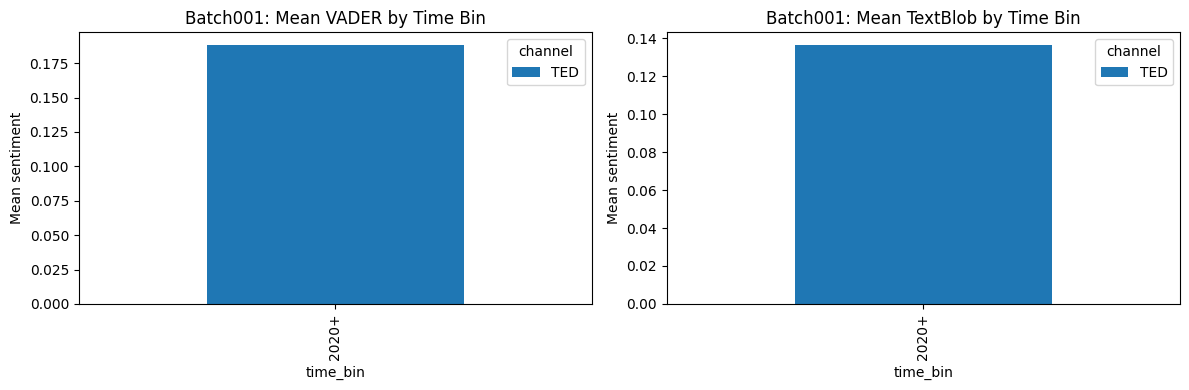

Saved figure: docs/week6_batch001_sentiment_by_timebin.png


In [54]:
import matplotlib.pyplot as plt
import numpy as np

pivot_vader = summary.pivot(index="time_bin", columns="channel", values="mean_vader")
pivot_tb = summary.pivot(index="time_bin", columns="channel", values="mean_textblob")

fig, axes = plt.subplots(1, 2, figsize=(12,4))

pivot_vader.plot(kind="bar", ax=axes[0])
axes[0].set_title("Batch001: Mean VADER by Time Bin")
axes[0].set_ylabel("Mean sentiment")

pivot_tb.plot(kind="bar", ax=axes[1])
axes[1].set_title("Batch001: Mean TextBlob by Time Bin")
axes[1].set_ylabel("Mean sentiment")

plt.tight_layout()

OUT_FIG = "docs/week6_batch001_sentiment_by_timebin.png"
plt.savefig(OUT_FIG, dpi=200)
plt.show()

print("Saved figure:", OUT_FIG)


## Resume Logic: Identify Already-Scraped Videos


In [56]:
import os, glob
import pandas as pd

RAW_DIR = "data/raw/week6"
chunk_files = sorted(glob.glob(os.path.join(RAW_DIR, "comments_chunk_*.csv")))
print("Found chunk files:", len(chunk_files))

done_video_ids = set()

bad_files = []
for f in chunk_files:
    # 1) skip truly empty files
    if os.path.getsize(f) == 0:
        bad_files.append((f, "0 bytes"))
        continue

    # 2) try reading; if it fails, record and skip
    try:
        tmp = pd.read_csv(f)
        if "video_id" not in tmp.columns:
            bad_files.append((f, "missing video_id column"))
            continue
        done_video_ids.update(tmp["video_id"].dropna().astype(str).unique())
    except pd.errors.EmptyDataError:
        bad_files.append((f, "EmptyDataError"))
        continue

print("Already scraped videos:", len(done_video_ids))
print("Bad/empty chunk files skipped:", len(bad_files))
for bf in bad_files[:5]:
    print(" -", bf)


Found chunk files: 4
Already scraped videos: 0
Bad/empty chunk files skipped: 4
 - ('data/raw/week6/comments_chunk_000.csv', 'EmptyDataError')
 - ('data/raw/week6/comments_chunk_001.csv', 'EmptyDataError')
 - ('data/raw/week6/comments_chunk_002.csv', 'EmptyDataError')
 - ('data/raw/week6/comments_chunk_003.csv', 'EmptyDataError')


In [57]:
import os, glob

for f in glob.glob("data/raw/week6/comments_chunk_*.csv"):
    os.remove(f)

print("Deleted empty chunk files")


Deleted empty chunk files


In [58]:
print(os.listdir("data/raw/week6"))


['ted_tedx_videos.csv', 'scrape_summary.csv', 'scrape_progress.csv']


In [61]:
import pandas as pd

videos = pd.read_csv("data/raw/week6/ted_tedx_videos.csv")
print(videos["channel"].value_counts())
print("Total videos:", len(videos))
videos.head()


channel
TEDx    20000
TED      5491
Name: count, dtype: int64
Total videos: 25491


,video_id,title,channel,published_at
0,iOTCsXd38Ng,What if plastic didn’t last forever? #TEDTalks,TED,2026-02-08T19:00:41Z
1,d1yfb93beSI,How to Introduce Yourself — and Get Hired | Re...,TED,2026-02-08T16:00:53Z
2,yrVtEkCC8uY,These ads could encourage people to think twic...,TED,2026-02-07T19:01:00Z
3,an6ZM0iCGQw,Let’s Build AI Data Centers in Space | Philip ...,TED,2026-02-06T16:00:07Z
4,bA9xGDsQADo,Today’s athletes ARE built different #TEDTalks,TED,2026-02-05T20:00:34Z


In [62]:
import os

if os.path.exists("data/raw/week6/scrape_progress.csv"):
    os.rename(
        "data/raw/week6/scrape_progress.csv",
        "data/raw/week6/scrape_progress_checkpoint_125.csv"
    )

print(os.listdir("data/raw/week6"))


['ted_tedx_videos.csv', 'comments_chunk_001.csv', 'comments_chunk_002.csv', 'comments_raw_merged_batch001.csv', 'comments_chunk_004.csv', 'comments_chunk_000.csv', 'comments_chunk_003.csv', 'scrape_progress_checkpoint_125.csv', 'scrape_summary.csv', 'comments_test_sample.csv']


In [63]:
import os, glob, shutil

RAW_DIR = "data/raw/week6"
ARCHIVE_DIR = "data/raw/week6/archive_checkpoint_125"

os.makedirs(ARCHIVE_DIR, exist_ok=True)

for f in glob.glob(os.path.join(RAW_DIR, "comments_chunk_*.csv")) + \
         glob.glob(os.path.join(RAW_DIR, "comments_raw_merged_*.csv")) + \
         glob.glob(os.path.join(RAW_DIR, "scrape_summary*.csv")):
    shutil.move(f, os.path.join(ARCHIVE_DIR, os.path.basename(f)))

print("Archived files to:", ARCHIVE_DIR)
print("Now in week6 raw:", os.listdir(RAW_DIR))
print("Archive contains:", os.listdir(ARCHIVE_DIR))


Archived files to: data/raw/week6/archive_checkpoint_125
Now in week6 raw: ['ted_tedx_videos.csv', 'archive_checkpoint_125', 'scrape_progress_checkpoint_125.csv', 'comments_test_sample.csv']
Archive contains: ['comments_chunk_001.csv', 'comments_chunk_002.csv', 'comments_raw_merged_batch001.csv', 'comments_chunk_004.csv', 'comments_chunk_000.csv', 'comments_chunk_003.csv', 'scrape_summary.csv']


In [64]:
import os
print(os.listdir("data/raw/week6"))


['ted_tedx_videos.csv', 'archive_checkpoint_125', 'scrape_progress_checkpoint_125.csv', 'comments_test_sample.csv']


In [65]:
import os, pandas as pd

RAW_DIR = "data/raw/week6"
progress_path = os.path.join(RAW_DIR, "scrape_progress.csv")

# Create fresh progress file ONLY if it doesn't exist
if not os.path.exists(progress_path):
    pd.DataFrame(columns=["video_id","status","n_comments","error"]).to_csv(progress_path, index=False)

print("✅ Progress file ready:", progress_path)
print("Raw week6 now:", os.listdir(RAW_DIR))


✅ Progress file ready: data/raw/week6/scrape_progress.csv
Raw week6 now: ['ted_tedx_videos.csv', 'archive_checkpoint_125', 'scrape_progress_checkpoint_125.csv', 'comments_test_sample.csv', 'scrape_progress.csv']


In [67]:
import os, glob, re

RAW_DIR = "data/raw/week6"

existing = glob.glob(os.path.join(RAW_DIR, "comments_chunk_*.csv"))

nums = []
for f in existing:
    m = re.search(r"comments_chunk_(\d+)\.csv$", os.path.basename(f))
    if m:
        nums.append(int(m.group(1)))

chunk_idx = max(nums) + 1 if nums else 1
print("Starting chunk_idx at:", chunk_idx)


Starting chunk_idx at: 1


In [68]:
chunk_path = f"{RAW_DIR}/comments_chunk_{chunk_idx:04d}.csv"


In [69]:
import pandas as pd

videos = pd.read_csv("data/raw/week6/ted_tedx_videos.csv")
print("Total videos:", len(videos))
print(videos["channel"].value_counts())
videos.head()


Total videos: 25491
channel
TEDx    20000
TED      5491
Name: count, dtype: int64


,video_id,title,channel,published_at
0,iOTCsXd38Ng,What if plastic didn’t last forever? #TEDTalks,TED,2026-02-08T19:00:41Z
1,d1yfb93beSI,How to Introduce Yourself — and Get Hired | Re...,TED,2026-02-08T16:00:53Z
2,yrVtEkCC8uY,These ads could encourage people to think twic...,TED,2026-02-07T19:01:00Z
3,an6ZM0iCGQw,Let’s Build AI Data Centers in Space | Philip ...,TED,2026-02-06T16:00:07Z
4,bA9xGDsQADo,Today’s athletes ARE built different #TEDTalks,TED,2026-02-05T20:00:34Z


In [70]:
done_video_ids = set(
    progress_df.loc[progress_df["status"] == "ok", "video_id"]
)

print("Already scraped videos:", len(done_video_ids))


Already scraped videos: 125


In [71]:
import re

existing_chunks = glob.glob(f"{RAW_DIR}/comments_chunk_*.csv")

chunk_nums = []
for f in existing_chunks:
    m = re.search(r"comments_chunk_(\d+)\.csv$", f)
    if m:
        chunk_nums.append(int(m.group(1)))

chunk_idx = max(chunk_nums) + 1 if chunk_nums else 1
print("Starting chunk index at:", chunk_idx)


Starting chunk index at: 1


In [72]:
BATCH_SIZE = 25      # save every 25 videos
MAX_COMMENTS = 500  # per video

comments_buffer = []
videos_in_batch = 0


In [76]:
import os

RAW_DIR = "data/raw/week6"
VIDEOS_PATH = os.path.join(RAW_DIR, "ted_tedx_videos.csv")
PROGRESS_PATH = os.path.join(RAW_DIR, "scrape_progress.csv")

print("RAW_DIR:", RAW_DIR)
print("VIDEOS_PATH exists?", os.path.exists(VIDEOS_PATH))
print("PROGRESS_PATH exists?", os.path.exists(PROGRESS_PATH))


RAW_DIR: data/raw/week6
VIDEOS_PATH exists? True
PROGRESS_PATH exists? True


In [77]:
import pandas as pd

if os.path.exists(PROGRESS_PATH):
    progress_df = pd.read_csv(PROGRESS_PATH)
    progress_df["video_id"] = progress_df["video_id"].astype(str)
    print("Loaded progress_df:", progress_df.shape)
else:
    progress_df = pd.DataFrame(columns=["video_id", "status", "n_comments", "error"])
    progress_df.to_csv(PROGRESS_PATH, index=False)
    print("Created new progress_df")


Loaded progress_df: (1276, 4)


In [78]:
from tqdm import tqdm

for _, row in tqdm(videos_df.iterrows(), total=len(videos_df)):
    video_id = row["video_id"]

    # 1) Skip already scraped videos
    if video_id in done_video_ids:
        continue

    try:
        # 2) FETCH COMMENTS HERE
        # 🔴 This line assumes you already have a function like:
        # fetch_comments(video_id, max_comments=500)
        comments = fetch_comments(video_id, max_comments=MAX_COMMENTS)

        for c in comments:
            c["video_id"] = video_id
            comments_buffer.append(c)

        status = "ok"
        n_comments = len(comments)
        error = ""

    except Exception as e:
        status = "error"
        n_comments = 0
        error = str(e)

    # 3) Log progress
    progress_df = pd.concat(
        [
            progress_df,
            pd.DataFrame([{
                "video_id": video_id,
                "status": status,
                "n_comments": n_comments,
                "error": error
            }])
        ],
        ignore_index=True
    )

    progress_df.to_csv(PROGRESS_PATH, index=False)
    done_video_ids.add(video_id)

    videos_in_batch += 1

    # 4) Save chunk every BATCH_SIZE videos
    if videos_in_batch >= BATCH_SIZE:
    if len(comments_buffer) > 0:
        chunk_path = f"{RAW_DIR}/comments_chunk_{chunk_idx:04d}.csv"
        pd.DataFrame(comments_buffer).to_csv(chunk_path, index=False)
        print(f"✅ Saved {len(comments_buffer)} comments -> {chunk_path}")
        chunk_idx += 1
    else:
        print(f"⚠️ Batch reached {BATCH_SIZE} videos but collected 0 comments — not saving a chunk.")

    comments_buffer = []
    videos_in_batch = 0

time.sleep(1)  # polite pause


  4%|▎         | 916/25491 [00:00<00:02, 9126.22it/s]

Saved 0 comments → data/raw/week6/comments_chunk_0047.csv
Saved 0 comments → data/raw/week6/comments_chunk_0048.csv
Saved 0 comments → data/raw/week6/comments_chunk_0049.csv
Saved 0 comments → data/raw/week6/comments_chunk_0050.csv
Saved 0 comments → data/raw/week6/comments_chunk_0051.csv
Saved 0 comments → data/raw/week6/comments_chunk_0052.csv
Saved 0 comments → data/raw/week6/comments_chunk_0053.csv
Saved 0 comments → data/raw/week6/comments_chunk_0054.csv
Saved 0 comments → data/raw/week6/comments_chunk_0055.csv
Saved 0 comments → data/raw/week6/comments_chunk_0056.csv
Saved 0 comments → data/raw/week6/comments_chunk_0057.csv


  6%|▌         | 1560/25491 [00:13<04:15, 93.53it/s]

Saved 0 comments → data/raw/week6/comments_chunk_0058.csv
Saved 0 comments → data/raw/week6/comments_chunk_0059.csv
Saved 0 comments → data/raw/week6/comments_chunk_0060.csv
Saved 0 comments → data/raw/week6/comments_chunk_0061.csv
Saved 0 comments → data/raw/week6/comments_chunk_0062.csv
Saved 0 comments → data/raw/week6/comments_chunk_0063.csv
Saved 0 comments → data/raw/week6/comments_chunk_0064.csv
Saved 0 comments → data/raw/week6/comments_chunk_0065.csv
Saved 0 comments → data/raw/week6/comments_chunk_0066.csv
Saved 0 comments → data/raw/week6/comments_chunk_0067.csv
Saved 0 comments → data/raw/week6/comments_chunk_0068.csv
Saved 0 comments → data/raw/week6/comments_chunk_0069.csv
Saved 0 comments → data/raw/week6/comments_chunk_0070.csv
Saved 0 comments → data/raw/week6/comments_chunk_0071.csv
Saved 0 comments → data/raw/week6/comments_chunk_0072.csv


  8%|▊         | 1942/25491 [00:31<09:35, 40.93it/s]

...

Saved 0 comments → data/raw/week6/comments_chunk_0176.csv


 18%|█▊        | 4545/25491 [02:51<14:30, 24.06it/s]

Saved 0 comments → data/raw/week6/comments_chunk_0177.csv


 18%|█▊        | 4563/25491 [02:52<13:13, 26.39it/s]


KeyboardInterrupt: 

In [79]:
import pandas as pd
import random

VIDEOS_PATH = "data/raw/week6/ted_tedx_videos.csv"
videos = pd.read_csv(VIDEOS_PATH)

print("videos rows:", len(videos))
print(videos.head())

# pick a random video_id to test
test_id = random.choice(videos["video_id"].astype(str).tolist())
print("Testing video_id:", test_id)

resp = youtube.commentThreads().list(
    part="snippet",
    videoId=test_id,
    maxResults=20,
    textFormat="plainText",
    order="relevance"
).execute()

print("Keys:", resp.keys())
print("items returned:", len(resp.get("items", [])))
print("totalResults:", resp.get("pageInfo", {}).get("totalResults"))


videos rows: 25491
      video_id                                              title channel  \
0  iOTCsXd38Ng     What if plastic didn’t last forever? #TEDTalks     TED   
1  d1yfb93beSI  How to Introduce Yourself — and Get Hired | Re...     TED   
2  yrVtEkCC8uY  These ads could encourage people to think twic...     TED   
3  an6ZM0iCGQw  Let’s Build AI Data Centers in Space | Philip ...     TED   
4  bA9xGDsQADo     Today’s athletes ARE built different #TEDTalks     TED   

           published_at  
0  2026-02-08T19:00:41Z  
1  2026-02-08T16:00:53Z  
2  2026-02-07T19:01:00Z  
3  2026-02-06T16:00:07Z  
4  2026-02-05T20:00:34Z  
Testing video_id: qdkpLKDOy1M
Keys: dict_keys(['kind', 'etag', 'pageInfo', 'items'])
items returned: 0
totalResults: 0


In [80]:
import pandas as pd, random
from googleapiclient.errors import HttpError

VIDEOS_PATH = "data/raw/week6/ted_tedx_videos.csv"
videos = pd.read_csv(VIDEOS_PATH)

sample_ids = random.sample(videos["video_id"].astype(str).tolist(), 10)

results = []
for vid in sample_ids:
    try:
        resp = youtube.commentThreads().list(
            part="snippet",
            videoId=vid,
            maxResults=5,
            textFormat="plainText",
            order="relevance"
        ).execute()
        n = len(resp.get("items", []))
        total = resp.get("pageInfo", {}).get("totalResults", None)
        results.append((vid, "ok", n, total, ""))
    except HttpError as e:
        results.append((vid, "http_error", 0, None, str(e)[:120]))
    except Exception as e:
        results.append((vid, "error", 0, None, str(e)[:120]))

for r in results:
    print(r)


('p-bSW0KQco4', 'ok', 0, 0, '')
('rlB8_wCVNzU', 'ok', 5, 5, '')
('-dSCcE0a9Cw', 'ok', 0, 0, '')
('cR9vxiigMmA', 'ok', 0, 0, '')
('Cg2sYFtevHE', 'ok', 5, 5, '')
('U9d1HCFOVNI', 'ok', 2, 2, '')
('JCBQhzoeQCs', 'ok', 4, 4, '')
('qvhn52ST0gc', 'ok', 5, 5, '')
('ES8n_MGwWF4', 'ok', 5, 5, '')
('ItJCpXtFE7A', 'ok', 1, 1, '')


In [81]:
test_ids = random.sample(videos["video_id"].astype(str).tolist(), 10)

resp = youtube.videos().list(
    part="status,statistics,snippet",
    id=",".join(test_ids)
).execute()

print("Returned videos:", len(resp.get("items", [])))

for item in resp.get("items", []):
    vid = item["id"]
    title = item["snippet"]["title"]
    comment_count = item.get("statistics", {}).get("commentCount", None)
    privacy = item.get("status", {}).get("privacyStatus", None)
    print(vid, "| privacy:", privacy, "| commentCount:", comment_count, "|", title[:60])


Returned videos: 10
Pm9-sUsNjM4 | privacy: public | commentCount: 0 | ¿Amor o Dependencia económica?. | Marité Villanueva | TEDxJa
KV3GAmW2bXg | privacy: public | commentCount: 0 | Indigenous Science at Kuruvungna | Samantha Morales Johnson 
4DRz_gCFRLU | privacy: public | commentCount: 0 | Treasures in the Trash | Pancy Pan | TEDxBBSG Youth
RL4TeUHXAP0 | privacy: public | commentCount: 14 | Algorithms in the wild: An African Guide to Dating after 30 
iQeta9jKjGY | privacy: public | commentCount: 2 | Noise to Notes | Bhadra Ramesh Nair | TEDxOOBSchool
nuXJFbJNltg | privacy: public | commentCount: 69 | John Doerr: Seeking salvation and profit in greentech
GL63J9jRUvo | privacy: public | commentCount: 3 | 971 nuances d'urbanisme | Axel GRAVA | TEDxPointeaPitre
dAjMXexeaIE | privacy: public | commentCount: 3 | Educate Her, Empower the Future | Abdul'ahad Dalhat | TEDxZa
Nf3KgLJEdjs | privacy: public | commentCount: 2 | Freedom from definition | Arna Magnea Danks Danks | TEDxReyk
re2IOxkp9

In [82]:
import os, glob
import pandas as pd

RAW_DIR = "data/raw/week6"
os.makedirs(RAW_DIR, exist_ok=True)

PROGRESS_PATH = os.path.join(RAW_DIR, "scrape_progress.csv")

if os.path.exists(PROGRESS_PATH):
    progress_df = pd.read_csv(PROGRESS_PATH, dtype={"video_id": str})
    print("Loaded progress:", progress_df.shape)
else:
    progress_df = pd.DataFrame(columns=["video_id","status","n_comments","error"])
    progress_df.to_csv(PROGRESS_PATH, index=False)
    print("Created new progress file:", PROGRESS_PATH)

done_video_ids = set(progress_df["video_id"].dropna().astype(str).unique())
print("Already done videos:", len(done_video_ids))


Loaded progress: (3525, 4)
Already done videos: 3524


In [83]:
chunk_files = sorted(glob.glob(os.path.join(RAW_DIR, "comments_chunk_*.csv")))
if len(chunk_files) == 0:
    chunk_idx = 1
else:
    # Find the largest existing chunk number and start after it
    last = os.path.basename(chunk_files[-1])  # comments_chunk_0123.csv
    last_num = int(last.split("_")[-1].replace(".csv",""))
    chunk_idx = last_num + 1

print("Next chunk index will be:", chunk_idx)


Next chunk index will be: 178


In [84]:
import os, glob

RAW_DIR = "data/raw/week6"
chunk_files = glob.glob(os.path.join(RAW_DIR, "comments_chunk_*.csv"))
sizes = [(f, os.path.getsize(f)) for f in chunk_files]
zero = [f for f,s in sizes if s == 0]
print("Chunk files:", len(chunk_files))
print("Zero-byte chunks:", len(zero))
if zero[:5]:
    print("Example zero-byte:", zero[:5])


Chunk files: 177
Zero-byte chunks: 0


In [85]:
VIDEOS_PATH = os.path.join(RAW_DIR, "ted_tedx_videos.csv")
videos_df = pd.read_csv(VIDEOS_PATH, dtype={"video_id": str})

print("Total videos in frame:", len(videos_df))
print(videos_df["channel"].value_counts())


Total videos in frame: 25491
channel
TEDx    20000
TED      5491
Name: count, dtype: int64


In [86]:
from googleapiclient.errors import HttpError

def fetch_top_level_comments(youtube, video_id, cap=500):
    comments = []
    page_token = None

    while True:
        try:
            resp = youtube.commentThreads().list(
                part="snippet",
                videoId=video_id,
                maxResults=100,           # max allowed per page
                pageToken=page_token,
                textFormat="plainText",
                order="relevance"
            ).execute()
        except HttpError as e:
            return [], "http_error", str(e)[:200]
        except Exception as e:
            return [], "error", str(e)[:200]

        items = resp.get("items", [])
        for it in items:
            top = it["snippet"]["topLevelComment"]["snippet"]
            comments.append({
                "video_id": video_id,
                "comment_id": it["id"],
                "text": top.get("textDisplay", ""),
                "like_count": top.get("likeCount", None),
                "published_at": top.get("publishedAt", None),
                "author": top.get("authorDisplayName", None),
            })
            if len(comments) >= cap:
                return comments[:cap], "ok", ""

        page_token = resp.get("nextPageToken")
        if not page_token:
            break

    return comments, "ok", ""


In [ ]:
def get_top_level_comments(youtube, video_id, max_comments=500):
    comments = []
    next_page = None

    while len(comments) < max_comments:
        resp = youtube.commentThreads().list(
            part="snippet",
            videoId=video_id,
            maxResults=100,
            pageToken=next_page,
            textFormat="plainText",
            order="relevance"
        ).execute()

        for item in resp.get("items", []):
            snippet = item["snippet"]["topLevelComment"]["snippet"]
            comments.append({
                "video_id": video_id,
                "comment_id": item["id"],
                "text": snippet["textDisplay"],
                "like_count": snippet.get("likeCount"),
                "published_at": snippet.get("publishedAt")
            })

            if len(comments) >= max_comments:
                break

        next_page = resp.get("nextPageToken")
        if not next_page:
            break

    return comments


In [87]:
from tqdm import tqdm
import time

BATCH_SIZE = 50          # save a chunk every 50 videos processed
CAP_PER_VIDEO = 500

comments_buffer = []
videos_in_batch = 0

for _, row in tqdm(videos_df.iterrows(), total=len(videos_df)):
    vid = str(row["video_id"])

    if vid in done_video_ids:
        continue

    comments, status, err = fetch_top_level_comments(youtube, vid, cap=CAP_PER_VIDEO)

    # record progress (always)
    progress_df.loc[len(progress_df)] = [vid, status, len(comments), err]
    progress_df.to_csv(PROGRESS_PATH, index=False)
    done_video_ids.add(vid)

    # buffer comments (only if any)
    if len(comments) > 0:
        comments_buffer.extend(comments)

    videos_in_batch += 1

    # save chunk every BATCH_SIZE videos, but ONLY if buffer has rows
    if videos_in_batch >= BATCH_SIZE:
        if len(comments_buffer) > 0:
            out_path = os.path.join(RAW_DIR, f"comments_chunk_{chunk_idx:04d}.csv")
            pd.DataFrame(comments_buffer).to_csv(out_path, index=False)
            print(f"✅ Saved {len(comments_buffer)} comments -> {out_path}")
            chunk_idx += 1
            comments_buffer = []
        else:
            print(f"⚠️ Processed {BATCH_SIZE} videos but collected 0 comments — no chunk saved.")
        videos_in_batch = 0

    time.sleep(0.2)  # polite pause


 14%|█▍        | 3574/25491 [00:33<11:17, 32.37it/s]

✅ Saved 5322 comments -> data/raw/week6/comments_chunk_0178.csv


 14%|█▍        | 3607/25491 [00:54<27:26, 13.29it/s]

✅ Saved 7911 comments -> data/raw/week6/comments_chunk_0179.csv


 14%|█▍        | 3674/25491 [01:55<2:39:46,  2.28it/s]

...

⚠️ Processed 50 videos but collected 0 comments — no chunk saved.


 42%|████▏     | 10774/25491 [53:32<1:04:38,  3.79it/s]

⚠️ Processed 50 videos but collected 0 comments — no chunk saved.


 42%|████▏     | 10774/25491 [53:32<1:13:08,  3.35it/s]


KeyboardInterrupt: 

In [88]:
import pandas as pd, os

RAW_DIR = "data/raw/week6"
PROGRESS_PATH = os.path.join(RAW_DIR, "scrape_progress.csv")

progress_df = pd.read_csv(PROGRESS_PATH, dtype={"video_id": str})
print("Progress rows:", progress_df.shape[0])
print(progress_df["status"].value_counts().head(10))
print("Unique videos in progress:", progress_df["video_id"].nunique())


Progress rows: 10776
status
ok            6187
error         3400
http_error    1189
Name: count, dtype: int64
Unique videos in progress: 10775


In [89]:
import glob, os

RAW_DIR = "data/raw/week6"
chunk_files = sorted(glob.glob(os.path.join(RAW_DIR, "comments_chunk_*.csv")))
print("Chunk files:", len(chunk_files))
print("Last 5 chunks:", chunk_files[-5:])


Chunk files: 302
Last 5 chunks: ['data/raw/week6/comments_chunk_0298.csv', 'data/raw/week6/comments_chunk_0299.csv', 'data/raw/week6/comments_chunk_0300.csv', 'data/raw/week6/comments_chunk_0301.csv', 'data/raw/week6/comments_chunk_0302.csv']


In [90]:
import os, glob, shutil

RAW_DIR = "data/raw/week6"
checkpoint_name = "archive_checkpoint_37pct"
ARCHIVE_DIR = os.path.join(RAW_DIR, checkpoint_name)

os.makedirs(ARCHIVE_DIR, exist_ok=True)

to_move = []
to_move += glob.glob(os.path.join(RAW_DIR, "comments_chunk_*.csv"))
to_move += glob.glob(os.path.join(RAW_DIR, "comments_raw_merged_*.csv"))
to_move += glob.glob(os.path.join(RAW_DIR, "scrape_summary.csv"))
to_move += glob.glob(os.path.join(RAW_DIR, "scrape_progress.csv"))

for f in to_move:
    shutil.copy2(f, os.path.join(ARCHIVE_DIR, os.path.basename(f)))

print("Archived to:", ARCHIVE_DIR)
print("Archive contains:", len(os.listdir(ARCHIVE_DIR)), "files")


Archived to: data/raw/week6/archive_checkpoint_37pct
Archive contains: 303 files


In [93]:
import pandas as pd

PROGRESS_PATH = "data/raw/week6/scrape_progress.csv"  # adjust if needed
progress = pd.read_csv(PROGRESS_PATH, dtype={"video_id": str})

print("Rows:", len(progress))
print(progress["status"].value_counts(dropna=False).head(20))
print("\nExamples of failures:")
print(progress.loc[progress["status"].astype(str).str.contains("get_top_level_comments", na=False), ["video_id","status"]].head(5))


Rows: 10776
status
ok            6187
error         3400
http_error    1189
Name: count, dtype: int64

Examples of failures:
Empty DataFrame
Columns: [video_id, status]
Index: []


In [11]:
import os
print(os.getcwd())
print(os.listdir("."))


/content/SOSC314_Project/SOSC314_Project
['README.md', 'config', 'docs', 'data', '.gitignore', 'scripts', '.git', 'Week 2_Figure.png', 'notebooks', 'Week_3_Figure.png']


In [13]:
!git clone https://github.com/mustafayubk/SOSC314_Project.git


Cloning into 'SOSC314_Project'...
remote: Enumerating objects: 404, done.
remote: Counting objects: 100% (205/205), done.
remote: Compressing objects: 100% (204/204), done.
remote: Total 404 (delta 120), reused 0 (delta 0), pack-reused 199 (from 2)
Receiving objects: 100% (404/404), 10.36 MiB | 14.92 MiB/s, done.
Resolving deltas: 100% (220/220), done.


In [14]:
import os

os.chdir("SOSC314_Project")
print("Current directory:", os.getcwd())
print("Repo contents:", os.listdir("."))


Current directory: /content/SOSC314_Project/SOSC314_Project/SOSC314_Project
Repo contents: ['README.md', 'config', 'docs', 'data', '.gitignore', 'scripts', '.git', 'Week 2_Figure.png', 'notebooks', 'Week_3_Figure.png']


In [18]:
import os

os.chdir("..")
print("Now in:", os.getcwd())
print("Contents:", os.listdir("."))


Now in: /content/SOSC314_Project/SOSC314_Project
Contents: ['README.md', 'config', 'docs', 'data', '.gitignore', 'scripts', '.git', 'Week 2_Figure.png', 'SOSC314_Project', 'notebooks', 'Week_3_Figure.png']


In [5]:
import os

print("PWD:", os.getcwd())
print("data contains:", os.listdir("data"))


PWD: /content/SOSC314_Project
data contains: ['data_dictionary.md', 'raw', 'video_list.csv', 'processed']


In [6]:
import os

print("data/raw exists?", os.path.exists("data/raw"))
if os.path.exists("data/raw"):
    print("data/raw contains:", os.listdir("data/raw"))


data/raw exists? True
data/raw contains: ['ted_tedx_videos.csv', 'fail_log_week3.csv', 'comments_chunk_001.csv', 'comments_chunk_002.csv', 'comments_raw_baseline.csv', 'comments_chunk_000.csv', 'comments_chunk_003.csv', 'fail_log.csv', 'comments_chunk_000 (1).csv', 'scrape_summary.csv', 'scrape_progress (1).csv', 'comments_raw_week3.csv', 'comments_test_sample.csv', '.gitkeep', 'scrape_progress.csv']


In [7]:
import glob

print("Found chunks:", len(glob.glob("**/comments_chunk_*.csv", recursive=True)))
print("Found scrape_progress:", glob.glob("**/scrape_progress*.csv", recursive=True)[:10])
print("Found scrape_summary:", glob.glob("**/scrape_summary*.csv", recursive=True)[:10])


Found chunks: 5
Found scrape_progress: ['data/raw/scrape_progress (1).csv', 'data/raw/scrape_progress.csv']
Found scrape_summary: ['data/raw/scrape_summary.csv']


In [8]:
import os
os.makedirs("data/raw/week6", exist_ok=True)


In [9]:
import glob, shutil

for f in glob.glob("data/raw/comments_chunk_*.csv"):
    shutil.move(f, "data/raw/week6/" + os.path.basename(f))

for f in glob.glob("data/raw/scrape_progress*.csv"):
    shutil.move(f, "data/raw/week6/" + os.path.basename(f))

for f in glob.glob("data/raw/scrape_summary*.csv"):
    shutil.move(f, "data/raw/week6/" + os.path.basename(f))


In [10]:
import os
print(os.listdir("data/raw/week6"))


['comments_chunk_001.csv', 'comments_chunk_002.csv', 'comments_chunk_000.csv', 'comments_chunk_003.csv', 'comments_chunk_000 (1).csv', 'scrape_summary.csv', 'scrape_progress (1).csv', 'scrape_progress.csv']


In [11]:
import glob, os

print("PWD:", os.getcwd())
print("week6 exists:", os.path.exists("data/raw/week6"))

chunk_files = sorted(glob.glob("data/raw/week6/comments_chunk_*.csv"))
print("Chunks found:", len(chunk_files))
print("First 3:", chunk_files[:3])
print("Last 3:", chunk_files[-3:])


PWD: /content/SOSC314_Project
week6 exists: True
Chunks found: 5
First 3: ['data/raw/week6/comments_chunk_000 (1).csv', 'data/raw/week6/comments_chunk_000.csv', 'data/raw/week6/comments_chunk_001.csv']
Last 3: ['data/raw/week6/comments_chunk_001.csv', 'data/raw/week6/comments_chunk_002.csv', 'data/raw/week6/comments_chunk_003.csv']


In [12]:
total_rows = 0
for f in chunk_files:
    with open(f, "r", encoding="utf-8", errors="ignore") as fh:
        total_rows += sum(1 for _ in fh) - 1  # minus header
print("Approx total comment rows:", total_rows)


Approx total comment rows: 2113


In [13]:
import glob

all_chunks = sorted(glob.glob("**/comments_chunk_*.csv", recursive=True))
print("Total chunk files found anywhere:", len(all_chunks))
print("First 20 paths:")
for p in all_chunks[:20]:
    print(" -", p)

print("\nLast 20 paths:")
for p in all_chunks[-20:]:
    print(" -", p)


Total chunk files found anywhere: 5
First 20 paths:
 - data/raw/week6/comments_chunk_000 (1).csv
 - data/raw/week6/comments_chunk_000.csv
 - data/raw/week6/comments_chunk_001.csv
 - data/raw/week6/comments_chunk_002.csv
 - data/raw/week6/comments_chunk_003.csv

Last 20 paths:
 - data/raw/week6/comments_chunk_000 (1).csv
 - data/raw/week6/comments_chunk_000.csv
 - data/raw/week6/comments_chunk_001.csv
 - data/raw/week6/comments_chunk_002.csv
 - data/raw/week6/comments_chunk_003.csv


In [14]:
import os
from collections import defaultdict

folder_counts = defaultdict(int)
for p in all_chunks:
    folder_counts[os.path.dirname(p)] += 1

print("Chunk files per folder:")
for folder, n in sorted(folder_counts.items(), key=lambda x: -x[1])[:15]:
    print(f"{n:>5}  {folder}")


Chunk files per folder:
    5  data/raw/week6


In [15]:
total_rows = 0
bad = 0

for f in all_chunks:
    try:
        with open(f, "r", encoding="utf-8", errors="ignore") as fh:
            total_rows += sum(1 for _ in fh) - 1
    except Exception:
        bad += 1

print("Approx total comment rows across ALL chunks:", total_rows)
print("Bad/unreadable files:", bad)


Approx total comment rows across ALL chunks: 2113
Bad/unreadable files: 0


In [16]:
import glob

all_chunks = glob.glob("/content/**/comments_chunk_*.csv", recursive=True)

print("Total chunk files found anywhere:", len(all_chunks))
for p in all_chunks[:10]:
    print(p)


Total chunk files found anywhere: 5
/content/SOSC314_Project/data/raw/week6/comments_chunk_001.csv
/content/SOSC314_Project/data/raw/week6/comments_chunk_002.csv
/content/SOSC314_Project/data/raw/week6/comments_chunk_000.csv
/content/SOSC314_Project/data/raw/week6/comments_chunk_003.csv
/content/SOSC314_Project/data/raw/week6/comments_chunk_000 (1).csv


In [17]:
import os
print("PWD:", os.getcwd())
print("Repo contents:", os.listdir("."))


PWD: /content/SOSC314_Project
Repo contents: ['README.md', 'config', 'docs', 'data', '.gitignore', 'scripts', '.git', 'Week 2_Figure.png', 'notebooks', 'Week_3_Figure.png']


In [18]:
import os

TARGET = "data/raw/week6"
print("Exists?", os.path.exists(TARGET))
if os.path.exists(TARGET):
    print("Contents:", os.listdir(TARGET))


Exists? True
Contents: ['comments_chunk_001.csv', 'comments_chunk_002.csv', 'comments_chunk_000.csv', 'comments_chunk_003.csv', 'comments_chunk_000 (1).csv', 'scrape_summary.csv', 'scrape_progress (1).csv', 'scrape_progress.csv']


In [19]:
import shutil, os

TARGET = "data/raw/week6"

if os.path.exists(TARGET):
    shutil.rmtree(TARGET)
    print("✅ Deleted:", TARGET)
else:
    print("⚠️ Folder not found, nothing deleted")


✅ Deleted: data/raw/week6


In [20]:
os.makedirs("data/raw/week6/comments_chunks", exist_ok=True)
print("✅ Recreated empty structure")
print(os.listdir("data/raw/week6"))


✅ Recreated empty structure
['comments_chunks']


In [21]:
import os

print("Current:", os.getcwd())
print("Top level:", os.listdir("."))

# If you see SOSC314_Project folder here, enter it:
if "SOSC314_Project" in os.listdir("."):
    os.chdir("SOSC314_Project")
    print("Moved into:", os.getcwd())
    print("Now contains:", os.listdir("."))

# If there is STILL another nested SOSC314_Project, go into it:
if "SOSC314_Project" in os.listdir(".") and "data" not in os.listdir("."):
    os.chdir("SOSC314_Project")
    print("Moved into nested:", os.getcwd())
    print("Now contains:", os.listdir("."))


Current: /content/SOSC314_Project
Top level: ['README.md', 'config', 'docs', 'data', '.gitignore', 'scripts', '.git', 'Week 2_Figure.png', 'notebooks', 'Week_3_Figure.png']


In [22]:
import os, shutil

TARGET = "data/raw/week6"

# 1) Show what's there first
print("Exists?", os.path.exists(TARGET))
if os.path.exists(TARGET):
    print("Contents:", os.listdir(TARGET)[:20])

# 2) Delete it (ONLY if you truly want to start over)
shutil.rmtree(TARGET, ignore_errors=True)
print("✅ Deleted:", TARGET)

# 3) Recreate base structure
os.makedirs(TARGET, exist_ok=True)
print("✅ Recreated:", TARGET, "->", os.listdir(TARGET))


Exists? True
Contents: ['comments_chunks']
✅ Deleted: data/raw/week6
✅ Recreated: data/raw/week6 -> []


In [39]:
import pandas as pd

VIDEOS_PATH = "data/raw/ted_tedx_videos.csv"   # <-- this file is visible on your left
videos_df = pd.read_csv(VIDEOS_PATH, dtype={"video_id": str})

print("Videos loaded:", len(videos_df))
print(videos_df[["video_id"]].head())


Videos loaded: 25491
      video_id
0  iOTCsXd38Ng
1  d1yfb93beSI
2  yrVtEkCC8uY
3  an6ZM0iCGQw
4  bA9xGDsQADo


In [40]:
API_KEY = "YOUR_API_KEY_HERE"


In [41]:
import os, pandas as pd, glob

RAW_DIR = "data/raw/week6"
os.makedirs(RAW_DIR, exist_ok=True)

PROGRESS_PATH = os.path.join(RAW_DIR, "scrape_progress.csv")

if os.path.exists(PROGRESS_PATH):
    progress_df = pd.read_csv(PROGRESS_PATH, dtype={"video_id": str})
    done_video_ids = set(progress_df["video_id"].astype(str))
    print("Loaded existing progress:", len(progress_df), "rows")
else:
    progress_df = pd.DataFrame(columns=["video_id","status","n_comments","error"])
    progress_df.to_csv(PROGRESS_PATH, index=False)
    done_video_ids = set()
    print("Created new progress file.")

# chunk index continues after last saved chunk
existing = sorted(glob.glob(os.path.join(RAW_DIR, "comments_chunk_*.csv")))
chunk_idx = len(existing)
print("Starting chunk_idx =", chunk_idx)
print("Already done videos =", len(done_video_ids))


Loaded existing progress: 0 rows
Starting chunk_idx = 0
Already done videos = 0


In [42]:
import pandas as pd

videos = pd.read_csv("data/raw/ted_tedx_videos.csv", dtype={"video_id": str})

print("Videos loaded:", len(videos))
print(videos.head())


Videos loaded: 25491
      video_id                                              title channel  \
0  iOTCsXd38Ng     What if plastic didn’t last forever? #TEDTalks     TED   
1  d1yfb93beSI  How to Introduce Yourself — and Get Hired | Re...     TED   
2  yrVtEkCC8uY  These ads could encourage people to think twic...     TED   
3  an6ZM0iCGQw  Let’s Build AI Data Centers in Space | Philip ...     TED   
4  bA9xGDsQADo     Today’s athletes ARE built different #TEDTalks     TED   

           published_at  
0  2026-02-08T19:00:41Z  
1  2026-02-08T16:00:53Z  
2  2026-02-07T19:01:00Z  
3  2026-02-06T16:00:07Z  
4  2026-02-05T20:00:34Z  


In [34]:
from googleapiclient.discovery import build

youtube = build("youtube", "v3", developerKey=API_KEY)

# any known public TED video id is fine; use one from your ted_tedx_videos.csv
test_id = videos["video_id"].astype(str).iloc[0]

resp = youtube.videos().list(part="statistics", id=test_id).execute()
print("OK - got response. commentCount:", resp["items"][0]["statistics"].get("commentCount"))


OK - got response. commentCount: 25


In [29]:
import os, pandas as pd

RAW_DIR = "data/raw/week6"
os.makedirs(RAW_DIR, exist_ok=True)

PROGRESS_PATH = os.path.join(RAW_DIR, "scrape_progress.csv")
SUMMARY_PATH  = os.path.join(RAW_DIR, "scrape_summary.csv")

# create fresh progress file if not exists
if not os.path.exists(PROGRESS_PATH):
    progress_df = pd.DataFrame(columns=["video_id","status","n_comments","error"])
    progress_df.to_csv(PROGRESS_PATH, index=False)
    print("✅ Created new scrape_progress.csv")
else:
    progress_df = pd.read_csv(PROGRESS_PATH, dtype={"video_id": str})
    print("✅ Loaded existing progress:", progress_df.shape)

# create fresh summary file if not exists
if not os.path.exists(SUMMARY_PATH):
    pd.DataFrame(columns=["timestamp","note"]).to_csv(SUMMARY_PATH, index=False)
    print("✅ Created new scrape_summary.csv")

done_ids = set(pd.read_csv(PROGRESS_PATH, dtype={"video_id": str})["video_id"].dropna().astype(str).unique())
print("Already done videos:", len(done_ids))


✅ Created new scrape_progress.csv
✅ Created new scrape_summary.csv
Already done videos: 0


In [35]:
import glob, os

chunk_files = sorted(glob.glob(os.path.join(RAW_DIR, "comments_chunk_*.csv")))
if len(chunk_files) == 0:
    chunk_idx = 1
else:
    last = os.path.basename(chunk_files[-1])  # comments_chunk_0123.csv
    last_num = int(last.split("_")[-1].replace(".csv",""))
    chunk_idx = last_num + 1

print("Next chunk index:", chunk_idx)


Next chunk index: 1


In [44]:
from googleapiclient.errors import HttpError
import time

def fetch_top_level_comments(youtube, video_id, cap=500):
    comments = []
    page_token = None
    try:
        while True:
            resp = youtube.commentThreads().list(
                part="snippet",
                videoId=video_id,
                maxResults=100,
                pageToken=page_token,
                textFormat="plainText"
            ).execute()

            for item in resp.get("items", []):
                snip = item["snippet"]["topLevelComment"]["snippet"]
                comments.append({
                    "video_id": video_id,
                    "comment_id": item["snippet"]["topLevelComment"]["id"],
                    "text": snip.get("textDisplay", ""),
                    "like_count": snip.get("likeCount", 0),
                    "published_at": snip.get("publishedAt", ""),
                    "author": snip.get("authorDisplayName", "")
                })
                if len(comments) >= cap:
                    return comments, "ok", None

            page_token = resp.get("nextPageToken")
            if not page_token:
                break

            time.sleep(0.2)

        return comments, "ok", None

    except HttpError as e:
        return [], "http_error", str(e)
    except Exception as e:
        return [], "error", str(e)


In [51]:
from tqdm import tqdm
import time

BATCH_SIZE = 50          # save a chunk every 50 videos processed
CAP_PER_VIDEO = 500

comments_buffer = []
videos_in_batch = 0

for _, row in tqdm(videos_df.iterrows(), total=len(videos_df)):
    vid = str(row["video_id"])

    if vid in done_video_ids:
        continue

    comments, status, err = fetch_top_level_comments(youtube, vid, cap=CAP_PER_VIDEO)

    # record progress (always)
    progress_df.loc[len(progress_df)] = [vid, status, len(comments), err]
    progress_df.to_csv(PROGRESS_PATH, index=False)
    done_video_ids.add(vid)

    # buffer comments (only if any)
    if len(comments) > 0:
        comments_buffer.extend(comments)

    videos_in_batch += 1

    # save chunk every BATCH_SIZE videos, but ONLY if buffer has rows
    if videos_in_batch >= BATCH_SIZE:
        if len(comments_buffer) > 0:
            out_path = os.path.join(RAW_DIR, f"comments_chunk_{chunk_idx:04d}.csv")
            pd.DataFrame(comments_buffer).to_csv(out_path, index=False)
            print(f"✅ Saved {len(comments_buffer)} comments -> {out_path}")
            chunk_idx += 1
            comments_buffer = []
        else:
            print(f"⚠️ Processed {BATCH_SIZE} videos but collected 0 comments — no chunk saved.")
        videos_in_batch = 0

    time.sleep(0.2)  # polite pause


 13%|█▎        | 3357/25491 [00:41<10:39, 34.64it/s]

✅ Saved 9778 comments -> data/raw/week6/comments_chunk_0066.csv


 13%|█▎        | 3409/25491 [01:42<1:41:47,  3.62it/s]

✅ Saved 15133 comments -> data/raw/week6/comments_chunk_0067.csv


 14%|█▎        | 3458/25491 [02:41<4:58:00,  1.23it/s]WARNING:googleapiclient.http:Encountered 403 Forbidden with reason "commentsDisabled"


...

✅ Saved 11198 comments -> data/raw/week6/comments_chunk_0079.csv


 16%|█▌        | 4065/25491 [12:55<10:10:22,  1.71s/it]

✅ Saved 15955 comments -> data/raw/week6/comments_chunk_0080.csv


 16%|█▌        | 4086/25491 [13:27<1:10:31,  5.06it/s]


KeyboardInterrupt: 

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [37]:
import pandas as pd, glob, os

progress = pd.read_csv("data/raw/week6/scrape_progress.csv", dtype={"video_id": str})
print("Progress rows:", len(progress))
print(progress["status"].value_counts().head(10))

chunks = glob.glob("data/raw/week6/comments_chunk_*.csv")
print("Chunk files:", len(chunks))


Progress rows: 0
Series([], Name: count, dtype: int64)
Chunk files: 0


In [31]:
import os
print("PWD:", os.getcwd())
print("week6 exists:", os.path.exists("data/raw/week6"))


PWD: /content/SOSC314_Project
week6 exists: True


In [46]:
import pandas as pd

progress = pd.read_csv("data/raw/week6/scrape_progress.csv", dtype={"video_id": str})
done = progress[progress["status"] == "ok"][["video_id"]].drop_duplicates()

print("Processed videos (ok):", len(done))
print("Total rows in progress file:", len(progress))
print(progress["status"].value_counts())


Processed videos (ok): 3276
Total rows in progress file: 3316
status
ok            3276
http_error      40
Name: count, dtype: int64


In [49]:
import pandas as pd, glob, os

RAW_WEEK6 = "data/raw/week6"
PROGRESS_PATH = os.path.join(RAW_WEEK6, "scrape_progress.csv")
MASTER_VIDEOS_PATH = "data/raw/ted_tedx_videos.csv"   # ✅ correct path

# 1) Load progress (what you've processed so far)
progress = pd.read_csv(PROGRESS_PATH, dtype={"video_id": str})
done = progress.loc[progress["status"] == "ok", "video_id"].dropna().astype(str).unique()

print("Progress rows:", len(progress))
print("OK videos:", len(done))
print(progress["status"].value_counts(dropna=False).head(10))

# 2) Load master video list (has published_at)
videos = pd.read_csv(MASTER_VIDEOS_PATH, dtype={"video_id": str})
videos["published_at"] = pd.to_datetime(videos["published_at"], errors="coerce", utc=True)

# 3) Filter to the videos you've successfully scraped
v_done = videos[videos["video_id"].isin(done)].copy()

print("\nDONE videos with valid published_at:", v_done["published_at"].notna().sum())
print("Earliest:", v_done["published_at"].min())
print("Latest:  ", v_done["published_at"].max())

# 4) Simple time-bin counts (by year)
v_done["year"] = v_done["published_at"].dt.year
print("\nVideos scraped by year (top 15 years by count):")
print(v_done["year"].value_counts().sort_index().tail(15))

# Optional: by month (last 24 months)
v_done["month"] = v_done["published_at"].dt.to_period("M").astype(str)
print("\nVideos scraped by month (last 24 bins):")
print(v_done["month"].value_counts().sort_index().tail(24))


Progress rows: 3316
OK videos: 3276
status
ok            3276
http_error      40
Name: count, dtype: int64

DONE videos with valid published_at: 3276
Earliest: 2016-08-12 17:08:39+00:00
Latest:   2026-02-08 19:00:41+00:00

Videos scraped by year (top 15 years by count):
year
2016     91
2017    267
2018    356
2019    289
2020    349
2021    239
2022    364
2023    414
2024    331
2025    519
2026     57
Name: count, dtype: int64

Videos scraped by month (last 24 bins):
month
2024-03    33
2024-04    33
2024-05    26
2024-06    24
2024-07    29
2024-08    24
2024-09    28
2024-10    32
2024-11    23
2024-12    30
2025-01    40
2025-02    43
2025-03    42
2025-04    35
2025-05    38
2025-06    44
2025-07    42
2025-08    41
2025-09    46
2025-10    55
2025-11    47
2025-12    46
2026-01    46
2026-02    11
Name: count, dtype: int64


/tmp/ipython-input-4020946833.py:32: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  v_done["month"] = v_done["published_at"].dt.to_period("M").astype(str)


In [50]:
import shutil, os, time

src = "data/raw/week6"
stamp = time.strftime("%Y%m%d_%H%M%S")
dst = f"data/raw/week6_backup_{stamp}"
shutil.copytree(src, dst)
print("Backed up to:", dst)


Backed up to: data/raw/week6_backup_20260210_111507


In [52]:
import glob

chunks = glob.glob("data/raw/week6/comments_chunk_*.csv")
print("Chunk files:", len(chunks))

total = 0
for f in chunks:
    total += sum(1 for _ in open(f)) - 1

print("Total comments so far:", total)


Chunk files: 81
Total comments so far: 841871


In [53]:
import shutil, os

src = "data/raw/week6"
zip_name = "week6_raw_backup"
shutil.make_archive(zip_name, "zip", src)
print("Made:", zip_name + ".zip", "size (MB):", os.path.getsize(zip_name + ".zip")/1e6)


Made: week6_raw_backup.zip size (MB): 62.486213
